## Il problema del braccio robotico 2D

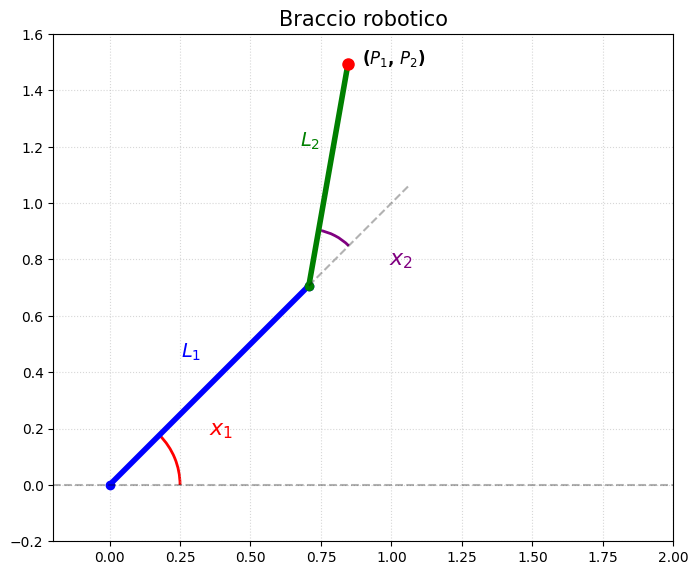

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Arc

# 1. Configurazione dei parametri
L1, L2 = 1.0, 0.8  # Lunghezze dei segmenti
x1 = np.radians(45)  # Angolo x1 in radianti (45°)
x2 = np.radians(35)  # Angolo x2 in radianti (35°)



def crea_grafico(L1,L2,x1_val,x2_val):
  #Funzione per creare il grafico di un braccio robotico con due giunti
  #Input:
  # L_1, L_2 : lunghezze dei due bracci
  # x1_val, x_2val : angoli (in radianti) dei bracci
  #Output:
  # fig : figura creata
  # p1,p2 : sono array di due componenti ciascuno contenenti le coordinate dell'estremità
  #         del secondo giunto
  # Posizione della base (Origine)
  p0 = np.array([0, 0])

  # Posizione del primo giunto (Gomito)
  p1 = np.array([L1 * np.cos(x1_val), L1 * np.sin(x1_val)])

  # Posizione dell'estremità del secondo braccio
  p2 = p1 + np.array([L2 * np.cos(x1_val + x2_val), L2 * np.sin(x1_val + x2_val)])

  #Creazione della figura
  fig, ax = plt.subplots(figsize=(8, 7))

  # Disegno dei bracci (segmenti blu e verdi)
  ax.plot([p0[0], p1[0]], [p0[1], p1[1]], 'o-', color='blue', lw=4, label='$L_1$')
  ax.plot([p1[0], p2[0]], [p1[1], p2[1]], 'o-', color='green', lw=4, label='$L_2$')

  # Asse Orizzontale
  ax.axhline(0, color='black', ls='--', alpha=0.3)

  # Prolungamento del primo braccio per mostrare l'angolo x2
  prolungamento = p1 + 0.5 * np.array([np.cos(x1_val), np.sin(x1_val)])
  ax.plot([p1[0], prolungamento[0]], [p1[1], prolungamento[1]], 'k--', alpha=0.3)

  # Disegno dell'arco per x1
  arc_x1 = Arc(p0, 0.5, 0.5, angle=0, theta1=0, theta2=np.degrees(x1_val),
              color='red', lw=2)
  ax.add_patch(arc_x1)
  r = 0.5
  modpi =  (x1_val + np.pi) % (2 * np.pi) - np.pi
  ax.text(np.cos(modpi)*r, np.sin(modpi/2)*r, '$x_1$', color='red', fontsize=16, fontweight='bold',va='center')

  # Disegno dell'arco per x2
  arc_x2 = Arc(p1, 0.4, 0.4, angle=np.degrees(x1_val), theta1=0, theta2=np.degrees(x2_val),
              color='purple', lw=2)
  ax.add_patch(arc_x2)
  r = 0.3
  ax.text(p1[0]+np.cos(x2_val/2)*r, p1[1]+np.sin(x2_val/2)*r, '$x_2$', color='purple', fontsize=16, fontweight='bold',va='center')

  # Etichette di testo
  ax.text(p1[0]/2-0.1, p1[1]/2+0.1, '$L_1$', color='blue', fontsize=14)
  ax.text((p1[0]+p2[0])/2-0.1, (p1[1]+p2[1])/2+0.1, '$L_2$', color='green', fontsize=14)

  ax.plot(p2[0], p2[1], 'ro', markersize=8) # estremità del secondo braccio
  ax.text(p2[0]+0.05, p2[1], '($P_1$, $P_2$)', fontsize=12, fontweight='bold')

  #Formattazione finale del grafico
  ax.set_xlim(-0.2, 2.0)
  ax.set_ylim(-0.2, 1.6)
  ax.set_aspect('equal')
  ax.set_title("Braccio robotico", fontsize=15)
  ax.grid(True, ls=':', alpha=0.5)
  #plt.close(fig)

  return fig, (p1,p2)

fig, (p1,p2) = crea_grafico(L1,L2,x1,x2)


## Descrizione del problema e modello matematico

Supponiamo di dover manovrare un braccio robotico a due giunti per prelevare un oggetto collocato in una posizione nota di coordinate $(P_1,P_2)$.

Per effettuare la manovra, il motore che muove il robot deve essere programmato tramite gli angoli indicati in figura con $(x_1,x_2)$, per posizionare correttamente i due bracci in modo che l'estremità del secondo si collochi esattamente nella posizione $(P_1,P_2)$


Applicando le regole della trigonometria, le equazioni che legano gli angoli $(x_1,x_2)$ alle coordinate dell'estremità del secondo braccio $(P_1, P_2)$ sono:

   $$\begin{cases}  L_1 \cos(x_1) + L_2 \cos(x_1 + x_2) = P_1 \\  L_1 \sin(x_1) + L_2 \sin(x_1 + x_2) = P_2 \end{cases}$$

Supponendo che $L_1,L_2$ siano le lunghezze (note) dei due bracci del robot, date le coordinate target $(P_1, P_2)$ si tratta di risolvere un sistema di due equazioni nonlineari nelle due incognite $(x_1,x_2)$.

Formalizziamo il sistema definendo le funzioni $f_1,f_2:\mathbb{R}^2\to\mathbb{R}$
$$\begin{array}{lcl} f_1(x_1,x_2)&=& L_1 \cos(x_1) + L_2 \cos(x_1 + x_2) - P_1 \\  f_2(x_1,x_2) &=& L_1 \sin(x_1) + L_2 \sin(x_1 + x_2) - P_2 \end{array}$$
che usiamo per definire il campo vettoriale $F:\mathbb{R}^2\to\mathbb{R}^2$
$$F(x_1,x_2) = \begin{pmatrix}f_1(x_1,x_2)\\f_2(x_1,x_2)\end{pmatrix} $$
da cui otteniamo l'espressione compatta del sistema
$$ F(x) = 0, \ \ x=\begin{pmatrix}x_1\\x_2\end{pmatrix}$$

**Jacobiano di $F$:**
La definizione generale è la seguente
$$JF(x) =\begin{pmatrix}
\frac{\partial f_1}{\partial x_1}(x) & \frac{\partial f_1}{\partial x_2}(x)\\
\frac{\partial f_2}{\partial x_1}(x) & \frac{\partial f_2}{\partial x_2}(x)
\end{pmatrix}$$
Nel caso particolare, abbiamo
$$JF(x) =\begin{pmatrix}
-L_1\sin(x_1) -L_2\sin(x_1+x_2) & -L_2\sin(x_1+x_2)\\
L_1\cos(x_1) + L_2\cos(x_1+x_2) & L_2\cos(x_1+x_2)
\end{pmatrix}$$

## Metodo di Newton per sistemi di equazioni nonlineari

Nel caso monodimensionale, dove cioè il problema è $f(x) = $ con $f:\mathbb{R}\to\mathbb{R}$, il metodo di Newton consiste nella formula di aggiornamento seguente
$$x_{k+1} = x_k - \frac{f(x_k)}{f'(x_k)} $$
che si può scrivere anche in due passi come
$$\begin{array}{lcl} d_k &=& - \displaystyle\frac{f(x_k)}{f'(x_k)}\\ x_{k+1} &=& x_k + d_k \end{array}$$

Il caso multidimensionale $F(x) = 0 $ dove $F:\mathbb{R}^n\to \mathbb{R}^n$
è del tutto analogo, secondo le seguenti corrispondenze (indicative)
$$\begin{array}{lcl}  f'(x_k) &\rightarrow & JF(x^{(k)})\\
d_k = - \displaystyle\frac{f(x_k)}{f'(x_k)} & \rightarrow & d^{(k)} = -JF(x^{(k)})^{-1}F(x^{(k)})\end{array} $$
In realtà, l'inversa della matrice jacobiana **NON** è assolutamente necessaria, perché ciò che serve è la soluzione di un sistema lineare.

Riassumendo, l'iterazione del metodo di Newton per sistemi consiste nei seguenti passi

1. calcola $JF(x^{(k)})$ e $F(x^{(k)})$
2. calcola la soluzione $d^{(k)}$  del sistema $JF(x^{(k)})d = -F(x^{(k)})$
3. $x^{(k+1)} = x^{(k)} + d^{(k)}$


**NB**: ad ogni passo del metodo di Newton è necessario risolvere un sistema lineare, pertanto il metodo è ben posto quando la matrice $JF(x^{(k)})$ è nonsingolare per ogni $k$.



In [3]:
def newton(F,JF,x0,tol,Nmax):
  Fx  = F(x0)   # Vettore con due termini noti dentro
  JFx = JF(x0)  # Matrice con quattro coefficienti dentro
  normF = np.linalg.norm(Fx)
  for k in range(Nmax):
    print(f"{k:3d}) ||F(x_k)|| = {normF}")  # Stampa del residuo
    try:
      # Tentiamo di risolvere il sistema lineare.
      # Qui fa Gauss con pivoting parziale, ma non ci interessa.
      # Se il sistema lineare non è risolvibile allora la matrice
      # dei coefficienti (Matrice Jacobiana) è singolare.
      d = np.linalg.solve(JFx,-Fx)
      x = x0 + d
    except np.linalg.LinAlgError:
      print("Errore: Matrice Jacobiana singolare.")
      return None
    Fx = F(x)     # Salviamo i termini noti del prossimo sistema lineare
    normF = np.linalg.norm(Fx)
    # Controllo sui criteri d'arresto
    # Distanza tra due iterate successive < tolleranza, e la norma minore della tolleranza 
    if np.linalg.norm(x-x0)/np.linalg.norm(x) < tol and normF < tol:
       print(f"{k+1:3d}) ||F(x_k)|| = {normF}")
       print("Convergenza raggiunta")
       return x
    JFx = JF(x)  # Ricalocliamo lo Jacobiano per il prossimo sistema
    x0 = x       # Propagazione del vettore incognito
  return x

In [4]:
#Definizione dei parametri e delle funzioni del modello
L1, L2 = 1.0, 0.8    # Lunghezze bracci
P_1, P_2 = 1.2, 0.5  # Posizione target

F = lambda x:  np.array([
            L1 * np.cos(x[0]) + L2 * np.cos(x[0] + x[1]) - P_1,
            L1 * np.sin(x[0]) + L2 * np.sin(x[0] + x[1]) - P_2])

JF = lambda x: np.array([
            [-L1*np.sin(x[0]) - L2*np.sin(x[0]+x[1]), -L2*np.sin(x[0]+x[1])],
            [ L1*np.cos(x[0]) + L2*np.cos(x[0]+x[1]),  L2*np.cos(x[0]+x[1])]
        ])

x0 = np.array([0.1, 0.1])  # angoli iniziali dei due bracci
tol=1e-6
Nmax=100


Posizione estremità 1.7790574275510191 0.2587688812828771


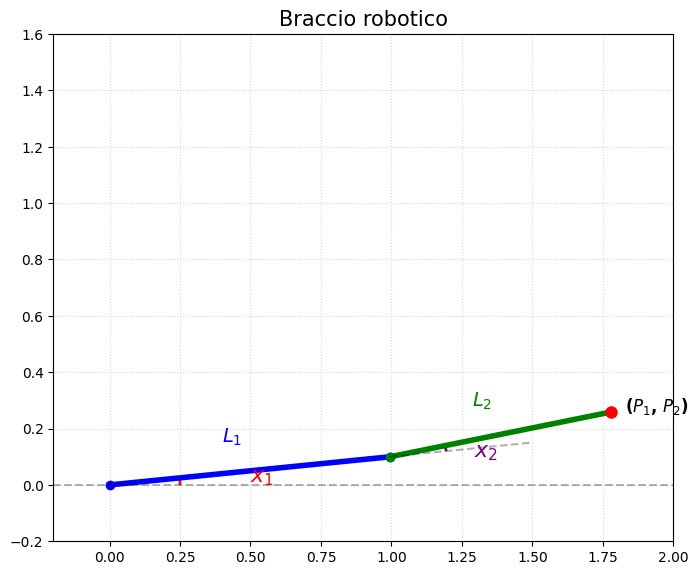

In [5]:
#Posizione iniziale del robot
fig, (p1,p2) = crea_grafico(L1,L2,x0[0],x0[1])
print("Posizione estremità",p2[0],p2[1])
p2_start = p2.copy()

In [6]:
sol = newton(F,JF,x0,tol,Nmax)
print("angoli dei giunti", sol)

  0) ||F(x_k)|| = 0.6272957492598834
  1) ||F(x_k)|| = 1.0513606109238705
  2) ||F(x_k)|| = 2.7488484352183105
  3) ||F(x_k)|| = 0.568268818805571
  4) ||F(x_k)|| = 2.8600549063153506
  5) ||F(x_k)|| = 0.4387965942028528
  6) ||F(x_k)|| = 0.09848682952004059
  7) ||F(x_k)|| = 0.006086772653870288
  8) ||F(x_k)|| = 1.8450968507469825e-05
  9) ||F(x_k)|| = 2.129858089395561e-10
 10) ||F(x_k)|| = 2.482534153247273e-16
Convergenza raggiunta
angoli dei giunti [-5.22590161 11.02682938]


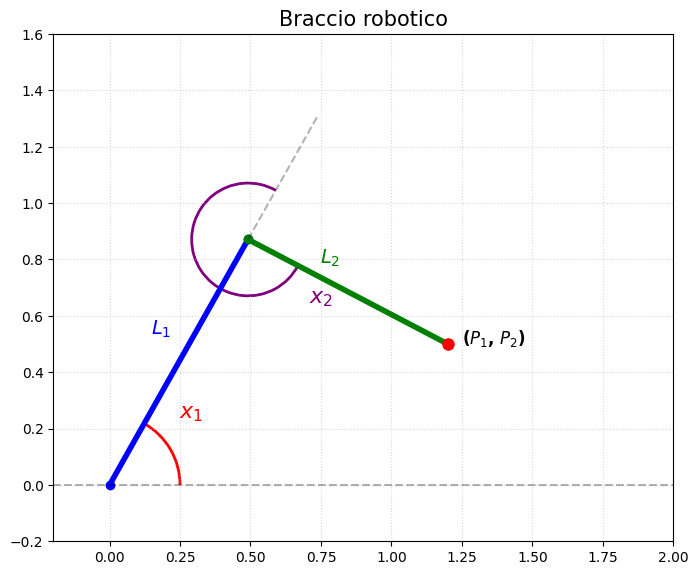

In [7]:
fig, (p1,p2) = crea_grafico(L1,L2,sol[0],sol[1])

In [8]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# Configurazioni angoli Iniziale e Finale (L1, L2 fissi)
start_angles = x0
end_angles   = sol
frames = 60 # Numero di frames dell'animazione

diff = (end_angles - start_angles + np.pi) % (2 * np.pi) - np.pi #a meno di giri

fig, ax = plt.subplots(figsize=(8, 7))
ax.set_xlim(-0.25, 2.0)
ax.set_ylim(-0.2, 1.6)
ax.set_aspect('equal')
ax.grid(True, ls=':', alpha=0.5)
target, = ax.plot(P_1,P_2,'ro',markersize=10,markerfacecolor = 'w')
text_target0 = ax.text(P_1, P_2-0.02, 'target', fontweight='bold',ha='center',va='top')
start, = ax.plot(p2_start[0],p2_start[1],'bo',markersize=10,markerfacecolor = 'w')
text_start = ax.text(p2_start[0], p2_start[1]-0.02, 'start', fontweight='bold',ha='center',va='top')
# Asse Orizzontale
ax.axhline(0, color='black', ls='--', alpha=0.3)


# Elementi grafici che verranno aggiornati
line1, = ax.plot([], [], 'o-', color='blue', lw=4)
line2, = ax.plot([], [], 'o-', color='green', lw=4)
text_target = ax.text(0, 0, '', fontweight='bold')
punto, = ax.plot([], [], 'ro', markersize=8)



def update(frame):
    # Interpolazione lineare tra gli angoli iniziali e quelli finali
    alpha = frame / (frames - 1)
    current_angles = start_angles + alpha * diff

    x1, x2 = current_angles[0], current_angles[1]

    p0 = np.array([0, 0])
    p1 = np.array([L1 * np.cos(x1), L1 * np.sin(x1)])
    p2 = p1 + np.array([L2 * np.cos(x1 + x2), L2 * np.sin(x1 + x2)])

    # Aggiornamento linee
    line1.set_data([p0[0], p1[0]], [p0[1], p1[1]])
    line2.set_data([p1[0], p2[0]], [p1[1], p2[1]])

    # Aggiornamento etichetta target
    text_target.set_position((p2[0]+0.05, p2[1]))
    text_target.set_text(f'P({p2[0]:.2f}, {p2[1]:.2f})')

    punto.set_data([p2[0]], [p2[1]]) # estremità del secondo braccio

    return line1, line2, text_target, punto

# Creazione animazione
ani = FuncAnimation(fig, update, frames=frames, interval=50, blit=True)

# Per visualizzarlo in Colab è necessario chiudere la figura "statica"
plt.close()

# Visualizzazione come video HTML5
HTML(ani.to_html5_video())

## Approfondimenti (1)

Il problema del braccio robotico come formulato finora
$$\begin{cases}  L_1 \cos(x_1) + L_2 \cos(x_1 + x_2) = P_1 \\  L_1 \sin(x_1) + L_2 \sin(x_1 + x_2) = P_2 \end{cases}$$
in realtà potrebbe essere risolto anche in forma semi-esplicita, come descritto qui nel seguito.

1. Si elevano al quadrato entrambi i membri delle due equazioni
$$\begin{cases}  L_1^2 \cos^2(x_1) + L_2^2 \cos^2(x_1 + x_2) + 2L_1L_2\cos(x_1)\cos(x_1+x_2) = P_1^2 \\  L_1^2 \sin^2(x_1) + L_2^2 \sin^2(x_1 + x_2) +2L_1L_2\sin(x_1)\sin(x_1+x_2)= P_2^2 \end{cases}$$

2. Si sommano le due equazioni e si applica l'uguaglianza trigonometrica fondamentale $\cos^2(x)+\sin^2(x) = 1$
$$\cos(x_1)\cos(x_1+x_2) + \sin(x_1)\sin(x_1+x_2) = \frac{P_1^2+P_2^2 - L_1^2-L_2^2}{2L_1L_2} $$
3. Applicando le formule di somma di seno e coseno si arriva a
$$\cos(x_2) = \underbrace{\frac{P_1^2+P_2^2 - L_1^2-L_2^2}{2L_1L_2}}_{c} $$
da cui si ricava direttamente $x_2 = \arccos(c)^{(*)}$.

4. Applichiamo le formule di somma di seno e coseno al sistema di partenza, che diventa
$$\begin{cases}  L_1 \cos(x_1) + L_2 (\cos(x_1)\cos(x_2) -\sin(x_1)\sin( x_2)) = P_1 \\  L_1 \sin(x_1) + L_2 (\sin(x_1)\cos(x_2) -\sin(x_2)\cos(x_1)) = P_2 \end{cases}$$

5. Sostituiamo i valori $s=\sin(x_2)$, $c=\cos(x_2)$ già ottenuti

$$\begin{cases}  (L_1+cL_2) \cos(x_1) -L_2s\sin(x_1) = P_1 \\  (L_1+cL_2) \sin(x_1) - L_2s\cos(x_1) = P_2 \end{cases}$$

Questo è un sistema lineare nelle incognite $\cos(x_1),\sin(x_1)$, con matrice dei coefficienti e termine noto
$$\begin{pmatrix}L_1+cL_2 & -sL_2\\ -sL_2 & L_1+cL_2 \end{pmatrix} , \begin{pmatrix} P_1\\P_2\end{pmatrix}$$


$^{(*)}$ In realtà non c'è un'unica soluzione, in generale.  Di solito si sceglie la più vicina all'angolo iniziale oppure si adotta una scelta tra le configurazioni a "gomito alto" o "gomito basso".



## Approfondimenti (2)

Una variante più significativa del problema del braccio robotico senza soluzione in forma chiusa si ha quando si considerano **giunti flessibili**.

In questo caso, i parametri con cui programmare il motore devono tenere conto  include una deformazione dovuta al peso dei bracci e dell'eventuale carico sulla punta.

Per programmare correttamente motore, il sistema da risolvere diventa

$$\begin{cases} L_1 \cos(q_1) + L_2 \cos(q_1 + q_2) = P_1 \\ L_1 \sin(q_1) + L_2 \sin(q_1 + q_2) = P_2 \end{cases}$$

dove
1. $x_1, x_2$: sono gli angoli impostati dai motori (le incognite).
2. $q_1, q_2$: sono gli angoli reali (fisici) della configurazione del braccio.
I controlli del motore sono legati agli angoli reali dalle relazioni
$$x_1 = q_1 + \frac{\tau_1}{k_1}, \ x_2 = q_2 + \frac{\tau_2}{k_2}$$
dove $\tau_1,\tau_2$ sono due funzioni di $q_1,q_2$ che rappresentano le forze che agiscono sui giunti.

In generale si tratta di funzioni nonlineari, come le seguenti

$$\tau_2(q_1,q_2) = \left( m_2 \frac{L_2}{2} + M_c L_2 \right) g \cos(q_1 + q_2)$$
$$\tau_1(q_1,q_2) = m_1 g \frac{L_1}{2} \cos(q_1) + m_2 g \left( L_1 \cos(q_1) + \frac{L_2}{2} \cos(q_1+q_2) \right) + M_c g \left( L_1 \cos(q_1) + L_2 \cos(q_1+q_2) \right)$$

Qui $g$ è l'accelerazione di gravità, $m_1,m_2$ sono le masse dei due bracci, $M_c$ è la massa dell'oggetto caricato sulla punta.

Una volta sostituite le espressioni di $q_1,q_2, \tau_1,\tau_2$ il sistema si può esplicitare in funzione delle incognite $x_1,x_2$.

In questo caso non è possibile costruire la formula chiusa come nel precedente, a causa delle dipendenze fortemente nonlineari delle incognite.

E' tuttavia ancora possibile procedere numericamente con il metodo di Newton.